# Linear / Ridge Regression + Categorical Preprocessor (scikit-learn)

This notebook builds a **reusable preprocessing handler** for linear models (and most classical ML models):
- Categorical features → `OneHotEncoder(handle_unknown='ignore')`
- Numeric features → impute + scale
- Export the fitted preprocessor with `joblib` into `ml-service/models/preprocessors/`

In [184]:
import sys
import json
from datetime import datetime, timezone
from pathlib import Path
from sklearn.metrics import make_scorer
from sklearn.base import clone
import numpy as np
import pandas as pd
import warnings
from sklearn.exceptions import ConvergenceWarning
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter, MaxNLocator
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge, HuberRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GroupShuffleSplit, GridSearchCV, KFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
import seaborn as sns
import joblib

def find_ml_root_for_import(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in (start, *start.parents):
        if (candidate / 'app' / 'core' / 'config.py').exists():
            return candidate
    raise FileNotFoundError('Could not locate ml-service root containing app/core/config.py')

ML_ROOT = find_ml_root_for_import()
if str(ML_ROOT) not in sys.path:
    sys.path.insert(0, str(ML_ROOT))


plt.style.use("seaborn-v0_8-dark")


from app.core.config import settings

## 1) Load Data

In [185]:
RANDOM_STATE = 42
TEST_SIZE = 0.2

TARGET_COL = 'price_egp'  # you can switch to 'price_egp_log' for a more linear-friendly target
DROP_COLS = {'price_egp', 'price_egp_log'}

df = settings.load_data('processed').copy()

# Clean basic string columns
for col in ['make', 'model', 'transmission', 'fuel', 'location', 'body_type', 'drivetrain', 'brand_origin', 'car_segment']:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip()

assert TARGET_COL in df.columns, f'Missing target column: {TARGET_COL}'

feature_cols = [c for c in df.columns if c not in DROP_COLS]
X = df[feature_cols].copy()
y = df[TARGET_COL].copy()

print('Rows:', len(df))
print('Features:', len(feature_cols))
print('Target:', TARGET_COL)
X.head()

Rows: 20461
Features: 16
Target: price_egp


,make,model,year,car_age,transmission,fuel,mileage_km,mileage_per_year,location,engine_cc,horsepower,body_type,drivetrain,seating_capacity,brand_origin,car_segment
0,BYD,F3,"2,024.000",2.000,Manual,petrol,"4,410.000","2,205.000",Cairo,1500,109,Sedan,FWD,5,chinese,family
1,BYD,F3,"2,025.000",1.000,Manual,petrol,"33,033.000","33,033.000",Nasr City,1500,109,Sedan,FWD,5,chinese,family
2,Subaru,Impreza,"2,009.000",17.000,Manual,petrol,"98,000.000","5,764.706",Maadi,1498,107,Sedan,AWD,5,japanese,family
3,BYD,F3,"2,024.000",2.000,Manual,petrol,"78,642.000","39,321.000",Cairo,1500,109,Sedan,FWD,5,chinese,family
4,Peugeot,206,"2,002.000",24.000,Manual,petrol,"200,000.000","8,333.333",Alexandria,1400,75,Hatchback,FWD,5,european,city


## 1.1) Quick Sanity Checks
Small checks to confirm dtypes, missing values, and basic target stats before modeling.

In [186]:
df.head()

,make,model,year,car_age,transmission,fuel,mileage_km,mileage_per_year,location,engine_cc,horsepower,body_type,drivetrain,seating_capacity,brand_origin,car_segment,price_egp,price_egp_log
0,BYD,F3,"2,024.000",2.000,Manual,petrol,"4,410.000","2,205.000",Cairo,1500,109,Sedan,FWD,5,chinese,family,630000,13.353
1,BYD,F3,"2,025.000",1.000,Manual,petrol,"33,033.000","33,033.000",Nasr City,1500,109,Sedan,FWD,5,chinese,family,610000,13.321
2,Subaru,Impreza,"2,009.000",17.000,Manual,petrol,"98,000.000","5,764.706",Maadi,1498,107,Sedan,AWD,5,japanese,family,410000,12.924
3,BYD,F3,"2,024.000",2.000,Manual,petrol,"78,642.000","39,321.000",Cairo,1500,109,Sedan,FWD,5,chinese,family,570000,13.253
4,Peugeot,206,"2,002.000",24.000,Manual,petrol,"200,000.000","8,333.333",Alexandria,1400,75,Hatchback,FWD,5,european,city,230000,12.346


In [187]:
df.dtypes.to_frame('dtype')

,dtype
make,str
model,str
year,float64
car_age,float64
transmission,str
fuel,str
mileage_km,float64
mileage_per_year,float64
location,str
engine_cc,int64


In [188]:
df[TARGET_COL].describe().to_frame('value')

,value
count,"20,461.000"
mean,"1,084,854.327"
std,"1,466,517.993"
min,"22,222.000"
25%,"330,000.000"
50%,"625,000.000"
75%,"1,200,000.000"
max,"20,000,000.000"


## 2) Split Strategies (5 ways)
We will evaluate:
- **A) Random train/test split (rows)**
- **B) 80/20 within each (make, model)** (rows held out, same make+model exists in train)
- **C) Split by make only** (hold out entire makes; hardest)
- **D) Random stratified split by `make`** (keeps brand distribution similar in train/test)
- **E) Random stratified split by **price range bins** (keeps target distribution similar in train/test)

In [189]:
rng = np.random.default_rng(RANDOM_STATE)

def split_random_rows(X: pd.DataFrame, y: pd.Series):
    return train_test_split(
        X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
    )

def split_stratified_by_make(df_full: pd.DataFrame, feature_cols: list[str], target_col: str):
    """Random split stratified by make to preserve brand ratios.

    Note: sklearn stratification requires each class to have >= 2 samples overall.
    We collapse extremely rare makes into 'RARE_MAKE' for stability.
    """
    make_counts = df_full["make"].value_counts()
    strat_col = df_full["make"].where(df_full["make"].map(make_counts) >= 2, "RARE_MAKE")

    idx = df_full.index.to_numpy()
    train_idx, test_idx = train_test_split(
        idx, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=strat_col
    )
    train_df = df_full.loc[train_idx]
    test_df = df_full.loc[test_idx]
    return (
        train_df[feature_cols],
        test_df[feature_cols],
        train_df[target_col],
        test_df[target_col],
)

def _build_strat_bins_from_price(price: pd.Series, desired_bins: int = 10) -> pd.Series:
    """Create robust stratification labels from a continuous price series.

    Uses quantile bins (qcut) and collapses rare bins (<2 rows) into a single 'RARE_BIN'.
    If qcut fails due to duplicates, it automatically reduces bin count.
    """
    s = pd.to_numeric(price, errors="coerce")
    s = s.fillna(s.median())

    # Try several bin counts to find something stratify-safe.
    for q in [desired_bins, 8, 6, 5, 4, 3]:
        try:
            b = pd.qcut(s, q=q, duplicates="drop")
        except Exception:
            continue

        # Use category codes (stable + compact) then collapse very small bins.
        codes = b.cat.codes.astype(int)
        counts = codes.value_counts()
        rare_codes = counts[counts < 2].index
        if len(rare_codes) > 0:
            codes = codes.where(~codes.isin(rare_codes), -1)
        # After collapsing, ensure all bins have >=2 samples
        if codes.value_counts().min() >= 2:
            return codes

    # Fallback: single bin (no stratification benefit, but avoids hard failure).
    return pd.Series(np.zeros(len(s), dtype=int), index=price.index)

def split_stratified_by_price_bins(
    df_full: pd.DataFrame,
    feature_cols: list[str],
    target_col: str,
    price_col_for_bins: str = "price_egp",
    desired_bins: int = 10,
):
    """Random split stratified by price-range bins.

    Stratification is based on `price_col_for_bins` (usually raw `price_egp`) even if the
    modeling target is `price_egp_log`.
    """
    if price_col_for_bins not in df_full.columns:
        price_col_for_bins = target_col  # fallback if raw price not present
    strat_bins = _build_strat_bins_from_price(df_full[price_col_for_bins], desired_bins=desired_bins)

    idx = df_full.index.to_numpy()
    train_idx, test_idx = train_test_split(
        idx, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=strat_bins
    )
    train_df = df_full.loc[train_idx]
    test_df = df_full.loc[test_idx]
    return (
        train_df[feature_cols],
        test_df[feature_cols],
        train_df[target_col],
        test_df[target_col],
)

def split_within_make_model_rows(df_full: pd.DataFrame):
    """Hold out ~20% rows within each (make, model).
    This matches the use-case: new listings for an already-known make+model.
    """
    min_rows_per_group = 5
    force_at_least_one_test_row = True

    train_idx: list[int] = []
    test_idx: list[int] = []

    for (_, _), gdf in df_full.groupby(["make", "model"], sort=False):
        n = len(gdf)
        if n < min_rows_per_group:
            train_idx.extend(gdf.index.to_list())
            continue

        n_test = int(np.floor(TEST_SIZE * n))
        if force_at_least_one_test_row:
            n_test = max(1, n_test)
        n_test = min(n_test, n - 1)  # keep at least one row in train
        chosen = rng.choice(gdf.index.to_numpy(), size=n_test, replace=False)
        chosen_set = set(chosen.tolist())

        test_idx.extend(list(chosen_set))
        train_idx.extend([i for i in gdf.index.to_list() if i not in chosen_set])

    train_df = df_full.loc[train_idx]
    test_df = df_full.loc[test_idx]

    assert set(train_idx).isdisjoint(set(test_idx))
    assert set(test_df["make"]).issubset(set(train_df["make"]))
    return train_df, test_df

def split_by_make_only(df_full: pd.DataFrame):
    """Hold out entire makes. Hardest split: test contains makes unseen during training."""
    splitter = GroupShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=RANDOM_STATE)
    groups = df_full["make"]
    train_idx, test_idx = next(splitter.split(df_full, groups=groups))
    train_df = df_full.iloc[train_idx]
    test_df = df_full.iloc[test_idx]

    assert set(test_df["make"]).isdisjoint(set(train_df["make"]))
    return train_df, test_df

# We'll build the splits dictionary in separate cells for clarity
splits: dict[str, tuple[pd.DataFrame, pd.DataFrame, pd.Series, pd.Series]] = {}

### A) Random rows split

In [190]:
X_tr, X_te, y_tr, y_te = split_random_rows(X, y)
splits["A_random_rows"] = (X_tr, X_te, y_tr, y_te)
print("A_random_rows", "| train:", len(X_tr), " test:", len(X_te))

A_random_rows | train: 16368  test: 4093


### B) 80/20 within each (make, model) (row holdout)

In [191]:
train_df, test_df = split_within_make_model_rows(df)

X_tr = train_df[feature_cols]
X_te = test_df[feature_cols]
y_tr = train_df[TARGET_COL]
y_te = test_df[TARGET_COL]

splits["B_within_make_model_rows"] = (X_tr, X_te, y_tr, y_te)
print("B_within_make_model_rows", "| train:", len(X_tr), " test:", len(X_te))

B_within_make_model_rows | train: 16560  test: 3901


### C) Split by make only (hold out brands)

In [192]:
train_df, test_df = split_by_make_only(df)

X_tr = train_df[feature_cols]
X_te = test_df[feature_cols]
y_tr = train_df[TARGET_COL]
y_te = test_df[TARGET_COL]

splits["C_split_by_make_only"] = (X_tr, X_te, y_tr, y_te)
print("C_split_by_make_only", "| train:", len(X_tr), " test:", len(X_te))
print("Held-out makes (test):", test_df['make'].nunique())

C_split_by_make_only | train: 15298  test: 5163
Held-out makes (test): 15


### D) Random stratified split by make (keeps brand ratios)

In [193]:
X_tr, X_te, y_tr, y_te = split_stratified_by_make(df, feature_cols=feature_cols, target_col=TARGET_COL)
splits["D_stratified_by_make"] = (X_tr, X_te, y_tr, y_te)
print("D_stratified_by_make", "| train:", len(X_tr), " test:", len(X_te))

# Quick check: compare make distribution (train vs test)
train_make = X_tr['make'].value_counts(normalize=True).rename('train')
test_make = X_te['make'].value_counts(normalize=True).rename('test')
train_make.to_frame().join(test_make.to_frame(), how='outer').fillna(0.0).head(10)

D_stratified_by_make | train: 16368  test: 4093


,train,test
make,,
Alfa Romeo,0.000,0.000
Audi,0.009,0.009
Avatr,0.002,0.001
BAIC,0.003,0.003
BMW,0.045,0.045
BYD,0.012,0.012
Brilliance,0.005,0.005
Cadillac,0.000,0.000
Chana,0.000,0.000


### E) Random stratified split by price range (bins)

In [194]:
X_tr, X_te, y_tr, y_te = split_stratified_by_price_bins(
    df,
    feature_cols=feature_cols,
    target_col=TARGET_COL,
    price_col_for_bins='price_egp',
    desired_bins=10,
)
splits["E_stratified_by_price_range"] = (X_tr, X_te, y_tr, y_te)

print("E_stratified_by_price_range", "| train:", len(X_tr), " test:", len(X_te))

# Quick check: stratification bin counts (after rare-bin collapsing)
bins = _build_strat_bins_from_price(df['price_egp'], desired_bins=10) if 'price_egp' in df.columns else _build_strat_bins_from_price(df[TARGET_COL], desired_bins=10)
bins.value_counts().head(10)

E_stratified_by_price_range | train: 16368  test: 4093


2    2166
0    2163
6    2102
5    2060
7    2039
4    2036
9    2023
8    1995
3    1942
1    1935
Name: count, dtype: int64

In [195]:
# Build split indices once so we can benchmark multiple targets fairly
# (same train/test rows, different y).
split_indices: dict[str, tuple[np.ndarray, np.ndarray]] = {
    name: (Xtr.index.to_numpy(), Xte.index.to_numpy())
    for name, (Xtr, Xte, _ytr, _yte) in splits.items()
}

print('Split index sets ready:', list(split_indices.keys()))
print('Example sizes:', {k: (len(v[0]), len(v[1])) for k, v in list(split_indices.items())[:2]})

Split index sets ready: ['A_random_rows', 'B_within_make_model_rows', 'C_split_by_make_only', 'D_stratified_by_make', 'E_stratified_by_price_range']
Example sizes: {'A_random_rows': (16368, 4093), 'B_within_make_model_rows': (16560, 3901)}


## 3) Preprocessor + Models
We auto-detect categorical vs numeric columns:
- Categorical: `object` / `category` → `OneHotEncoder(handle_unknown='ignore')`
- Numeric: everything else → `SimpleImputer(median)` + `StandardScaler`

Then we compare **LinearRegression** vs **Ridge** (often more stable with many one-hot features).

In [196]:
categorical_cols = X.select_dtypes(include=["object", "category", "string"]).columns.tolist()
numeric_cols = [c for c in X.columns if c not in categorical_cols]

print("Categorical cols (one-hot):", categorical_cols)
print("Numeric cols (scale):", numeric_cols)

numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_cols),
        ("cat", categorical_pipeline, categorical_cols),
    ],
    remainder="drop",
)

models = {
    "LinearRegression": LinearRegression(),
    "Ridge(alpha=1.0)": Ridge(alpha=1.0),
}

Categorical cols (one-hot): ['make', 'model', 'transmission', 'fuel', 'location', 'body_type', 'drivetrain', 'brand_origin', 'car_segment']
Numeric cols (scale): ['year', 'car_age', 'mileage_km', 'mileage_per_year', 'engine_cc', 'horsepower', 'seating_capacity']


## 4) Metrics + Evaluation
We’ll fit a full pipeline: `preprocessor → model`, then evaluate on each split.

In [197]:
def compute_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict:
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    mae = float(mean_absolute_error(y_true, y_pred))
    mse = float(mean_squared_error(y_true, y_pred))
    rmse = float(np.sqrt(mse))

    # MAPE: robust to zeros
    eps = 1e-9
    denom = np.maximum(np.abs(y_true), eps)
    mape = float(np.mean(np.abs((y_true - y_pred) / denom)) * 100.0)

    r2 = float(r2_score(y_true, y_pred))
    return {"MAE": mae, "MSE": mse, "RMSE": rmse, "MAPE_%": mape, "R2": r2}


In [198]:
# Display formatting: avoid scientific notation, keep <=3 decimals
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')
np.set_printoptions(suppress=True)

### Cross-validation + hyperparameter tuning
We tune **Ridge** regularization strength (`alpha`) using CV on the training split only.

In [199]:
# Training config: keep both models, skip expensive re-tuning by default
ENABLE_HYPERPARAM_TUNING = False
CV_FOLDS = 5
cv = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

# Fixed params used when tuning is disabled
FIXED_RIDGE_ALPHA = 0.01
FIXED_HUBER_ALPHA = 0.0
FIXED_HUBER_EPSILON = 1.3
HUBER_MAX_ITER = 2000

RIDGE_ALPHA_GRID = [0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]

def log_to_price(y_log: np.ndarray | pd.Series) -> np.ndarray:
    """Back-transform log target to price using exp (single log convention)."""
    return np.exp(np.asarray(y_log, dtype=float))

def mae_price_from_log(y_true_log, y_pred_log):
    y_true = log_to_price(y_true_log)
    y_pred = log_to_price(y_pred_log)
    return mean_absolute_error(y_true, y_pred)

def tune_ridge_pipeline(Xtr: pd.DataFrame, ytr: pd.Series, *, y_is_log: bool = False):
    """Return fitted Ridge pipeline and metadata.

    When ENABLE_HYPERPARAM_TUNING=False, this fits one fixed alpha and skips CV.
    """
    if not ENABLE_HYPERPARAM_TUNING:
        pipe = Pipeline(steps=[("preprocess", preprocessor), ("model", Ridge(alpha=FIXED_RIDGE_ALPHA))])
        pipe.fit(Xtr, ytr)
        return pipe, {"model__alpha": float(FIXED_RIDGE_ALPHA)}, np.nan, pd.DataFrame()

    ridge = Ridge()
    pipe = Pipeline(steps=[("preprocess", preprocessor), ("model", ridge)])

    scoring = make_scorer(mae_price_from_log, greater_is_better=False) if y_is_log else "neg_mean_absolute_error"

    grid = GridSearchCV(
        estimator=pipe,
        param_grid={"model__alpha": RIDGE_ALPHA_GRID},
        scoring=scoring,
        cv=cv,
        n_jobs=-1,
        refit=True,
    )
    grid.fit(Xtr, ytr)

    cv_results = pd.DataFrame(grid.cv_results_)
    best_cv_mae = float(-grid.best_score_)
    return grid.best_estimator_, grid.best_params_, best_cv_mae, cv_results

In [200]:
# We'll benchmark multiple targets using the SAME split indices (fair comparison)
TARGETS_TO_BENCH = [c for c in ["price_egp", "price_egp_log"] if c in df.columns]
print("Targets to benchmark:", TARGETS_TO_BENCH)

results_by_target: dict[str, pd.DataFrame] = {}
pred_store_by_target: dict[str, dict[str, dict]] = {}

print("Ready. Next cells will benchmark all splits for each target.")

Targets to benchmark: ['price_egp', 'price_egp_log']
Ready. Next cells will benchmark all splits for each target.


In [201]:
def sparse_to_dense(x):
    return x.toarray() if hasattr(x, "toarray") else x

def build_pipeline(model_name: str, row: pd.Series):
    """Build a fresh pipeline from selected/fixed hyperparameters."""
    if model_name == "Ridge(tuned)":
        alpha = float(row.get("best_alpha", FIXED_RIDGE_ALPHA))
        return Pipeline([
            ("preprocess", clone(preprocessor)),
            ("model", Ridge(alpha=alpha, fit_intercept=True)),
        ])

    if model_name == "HuberRegressor(tuned)":
        alpha = float(row.get("best_huber_alpha", FIXED_HUBER_ALPHA))
        epsilon = float(row.get("best_huber_epsilon", FIXED_HUBER_EPSILON))
        return Pipeline([
            ("preprocess", clone(preprocessor)),
            ("to_dense", FunctionTransformer(sparse_to_dense, accept_sparse=True)),
            ("model", HuberRegressor(alpha=alpha, epsilon=epsilon, max_iter=HUBER_MAX_ITER, warm_start=True)),
        ])

    if model_name == "LinearRegression":
        return Pipeline([
            ("preprocess", clone(preprocessor)),
            ("model", LinearRegression()),
        ])

    raise ValueError(f"Unknown model '{model_name}'. Add it to build_pipeline() before saving.")

def compute_metrics_in_egp(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    *,
    y_is_log: bool,
    ):
    """Return MAE/RMSE/MAPE/R2 in EGP for both raw-price and log-price targets."""
    if not y_is_log:
        y_true_arr = np.asarray(y_true, dtype=float)
        y_pred_arr = np.asarray(y_pred, dtype=float)
        return compute_metrics(y_true_arr, y_pred_arr), y_true_arr, y_pred_arr

    y_true_egp = log_to_price(y_true)
    y_pred_egp = log_to_price(y_pred)
    return compute_metrics(y_true_egp, y_pred_egp), y_true_egp, y_pred_egp

def fit_and_eval_linear(
    Xtr: pd.DataFrame,
    ytr: pd.Series,
    Xte: pd.DataFrame,
    yte: pd.Series,
    *,
    y_is_log: bool,
    ):
    pipe = Pipeline(steps=[("preprocess", preprocessor), ("model", LinearRegression())])
    pipe.fit(Xtr, ytr)
    preds = pipe.predict(Xte)
    metrics, y_true_eval, y_pred_eval = compute_metrics_in_egp(yte, preds, y_is_log=y_is_log)
    return pipe, preds, metrics, y_true_eval, y_pred_eval

def fit_and_eval_ridge_tuned(
    Xtr: pd.DataFrame,
    ytr: pd.Series,
    Xte: pd.DataFrame,
    yte: pd.Series,
    *,
    y_is_log: bool,
    ):
    best_pipe, best_params, best_cv_mae, cv_results = tune_ridge_pipeline(Xtr, ytr, y_is_log=y_is_log)
    preds = best_pipe.predict(Xte)
    metrics, y_true_eval, y_pred_eval = compute_metrics_in_egp(yte, preds, y_is_log=y_is_log)
    return best_pipe, preds, metrics, best_params, best_cv_mae, cv_results

def fit_and_eval_huber(
    Xtr: pd.DataFrame,
    ytr: pd.Series,
    Xte: pd.DataFrame,
    yte: pd.Series,
    *,
    y_is_log: bool,
    epsilon: float = FIXED_HUBER_EPSILON,
    alpha: float = FIXED_HUBER_ALPHA,
    max_iter: int = HUBER_MAX_ITER,
    ):
    """HuberRegressor trial (Huber loss; more robust to outliers)."""
    to_dense = FunctionTransformer(sparse_to_dense, accept_sparse=True)
    huber = HuberRegressor(epsilon=epsilon, alpha=alpha, max_iter=max_iter, warm_start=True)
    pipe = Pipeline(steps=[("preprocess", preprocessor), ("to_dense", to_dense), ("model", huber)])

    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=ConvergenceWarning)
        pipe.fit(Xtr, ytr)

    preds = pipe.predict(Xte)
    metrics, y_true_eval, y_pred_eval = compute_metrics_in_egp(yte, preds, y_is_log=y_is_log)
    return pipe, preds, metrics, y_true_eval, y_pred_eval

## 4.1) Run models per split (small cells)
Each split below fits:
- **LinearRegression**
- **Ridge** (fixed alpha by default; optional CV only when enabled)
- **HuberRegressor** (fixed params by default)

In [202]:
def build_splits_for_target(target_col: str):
    assert target_col in df.columns, f"Missing target column: {target_col}"
    splits_t: dict[str, tuple[pd.DataFrame, pd.DataFrame, pd.Series, pd.Series]] = {}
    for name, (tr_idx, te_idx) in split_indices.items():
        Xtr = df.loc[tr_idx, feature_cols]
        Xte = df.loc[te_idx, feature_cols]
        ytr = df.loc[tr_idx, target_col]
        yte = df.loc[te_idx, target_col]
        splits_t[name] = (Xtr, Xte, ytr, yte)
    return splits_t

def run_split(
    split_key: str,
    splits_dict: dict[str, tuple[pd.DataFrame, pd.DataFrame, pd.Series, pd.Series]],
    *,
    train_target: str,
    y_is_log: bool,
    rows_out: list[dict],
    pred_store_out: dict[str, dict],
    ):
    Xtr, Xte, ytr, yte = splits_dict[split_key]

    # LinearRegression
    lin_pipe, lin_preds_raw, lin_m, y_true_eval, lin_pred_eval = fit_and_eval_linear(
        Xtr, ytr, Xte, yte, y_is_log=y_is_log
    )
    rows_out.append({"split": split_key, "model": "LinearRegression", **lin_m})

    # Ridge (fixed by default; CV only when ENABLE_HYPERPARAM_TUNING=True)
    ridge_pipe, ridge_preds_raw, ridge_m, ridge_params, ridge_cv_mae, ridge_cv_results = fit_and_eval_ridge_tuned(
        Xtr, ytr, Xte, yte, y_is_log=y_is_log
    )
    ridge_pred_eval = compute_metrics_in_egp(yte, ridge_preds_raw, y_is_log=y_is_log)[2]
    rows_out.append({
        "split": split_key,
        "model": "Ridge(tuned)",
        "best_alpha": float(ridge_params["model__alpha"]),
        "cv_MAE": np.nan if pd.isna(ridge_cv_mae) else float(ridge_cv_mae),
        **ridge_m,
    })

    # HuberRegressor (fixed params by default)
    huber_pipe, huber_preds_raw, huber_m, _y_true_eval2, huber_pred_eval = fit_and_eval_huber(
        Xtr, ytr, Xte, yte, y_is_log=y_is_log
    )
    rows_out.append({
        "split": split_key,
        "model": "HuberRegressor(tuned)",
        "best_huber_alpha": float(FIXED_HUBER_ALPHA),
        "best_huber_epsilon": float(FIXED_HUBER_EPSILON),
        **huber_m,
    })

    pred_store_out[split_key] = {
        "y_true_eval": np.asarray(y_true_eval, dtype=float),
        "preds_linear_eval": np.asarray(lin_pred_eval, dtype=float),
        "preds_ridge_eval": np.asarray(ridge_pred_eval, dtype=float),
        "preds_huber_eval": np.asarray(huber_pred_eval, dtype=float),
        "train_target": train_target,
        "ridge_cv_mae": np.nan if pd.isna(ridge_cv_mae) else float(ridge_cv_mae),
        "ridge_cv_results": ridge_cv_results,
        "fitted_pipes": {
            "LinearRegression": lin_pipe,
            "Ridge(tuned)": ridge_pipe,
            "HuberRegressor(tuned)": huber_pipe,
        },
    }
    return None

def benchmark_target(target_col: str, split_keys: list[str] | None = None):
    splits_t = build_splits_for_target(target_col)
    split_keys = split_keys or list(splits_t.keys())

    y_is_log = target_col.endswith("_log")

    rows: list[dict] = []
    pred_store_local: dict[str, dict] = {}
    for k in split_keys:
        run_split(
            k,
            splits_t,
            train_target=target_col,
            y_is_log=y_is_log,
            rows_out=rows,
            pred_store_out=pred_store_local,
        )

    results_t = pd.DataFrame(rows)

    for col in ["best_alpha", "cv_MAE", "best_huber_alpha", "best_huber_epsilon"]:
        if col not in results_t.columns:
            results_t[col] = np.nan

    results_t = results_t.sort_values(["split", "MAE"]).reset_index(drop=True)
    results_t.insert(0, "train_target", target_col)
    results_t.insert(1, "eval_space", "EGP")
    return results_t, pred_store_local

### Benchmark target: `price_egp`

In [203]:
if "price_egp" in TARGETS_TO_BENCH:
    results_price, pred_price = benchmark_target("price_egp")
    results_by_target["price_egp"] = results_price
    pred_store_by_target["price_egp"] = pred_price
    results_price
else:
    print("price_egp not found in df.columns")

### Benchmark target: `price_egp_log`

In [204]:
if "price_egp_log" in TARGETS_TO_BENCH:
    results_log, pred_log = benchmark_target("price_egp_log")
    results_by_target["price_egp_log"] = results_log
    pred_store_by_target["price_egp_log"] = pred_log
    results_log
else:
    print("price_egp_log not found in df.columns")

In [205]:
# Combined summary table across both training targets (all metrics evaluated in EGP)
if len(results_by_target) == 0:
    raise RuntimeError("Run the benchmark cells above first (price_egp / price_egp_log).")

results_all = pd.concat(list(results_by_target.values()), ignore_index=True, axis=0)

# Reorder columns for readability
col_order = [
    "train_target",
    "split", "model", "MAE", "RMSE", "MAPE_%", "R2",
]
existing = [c for c in col_order if c in results_all.columns]
results_all = results_all[existing]

# Sort for quick scanning
results_all = results_all.sort_values(["train_target", "split", "MAE"]).reset_index(drop=True)
results_all

,train_target,split,model,MAE,RMSE,MAPE_%,R2
0,price_egp,A_random_rows,HuberRegressor(tuned),"249,886.676","666,558.185",31.187,0.816
1,price_egp,A_random_rows,LinearRegression,"284,655.261","628,165.236",49.195,0.837
2,price_egp,A_random_rows,Ridge(tuned),"284,780.948","627,838.458",49.488,0.837
3,price_egp,B_within_make_model_rows,HuberRegressor(tuned),"239,402.337","688,467.560",31.364,0.769
4,price_egp,B_within_make_model_rows,LinearRegression,"272,890.979","654,964.914",51.482,0.791
5,price_egp,B_within_make_model_rows,Ridge(tuned),"273,331.828","654,224.169",51.654,0.792
6,price_egp,C_split_by_make_only,Ridge(tuned),"1,069,857.364","1,541,925.016",236.461,-1.103
7,price_egp,C_split_by_make_only,HuberRegressor(tuned),"1,121,223.423","1,629,384.491",245.663,-1.349
8,price_egp,C_split_by_make_only,LinearRegression,"1,344,120.047","1,771,346.117",314.263,-1.776
9,price_egp,D_stratified_by_make,HuberRegressor(tuned),"257,690.505","758,842.936",30.714,0.720


In [206]:
# Pretty formatting: metrics are evaluated in EGP for BOTH targets
fmt_all = results_all.copy()

for c in ["MAE", "RMSE", "cv_MAE"]:
    if c in fmt_all.columns:
        fmt_all[c] = fmt_all[c].apply(lambda v: "" if pd.isna(v) else f"{float(v):,.0f}")

for c in ["MAPE_%", "R2", "best_alpha"]:
    if c in fmt_all.columns:
        fmt_all[c] = fmt_all[c].apply(lambda v: "" if pd.isna(v) else f"{float(v):.3f}")

fmt_all

,train_target,split,model,MAE,RMSE,MAPE_%,R2
0,price_egp,A_random_rows,HuberRegressor(tuned),"249,887","666,558",31.187,0.816
1,price_egp,A_random_rows,LinearRegression,"284,655","628,165",49.195,0.837
2,price_egp,A_random_rows,Ridge(tuned),"284,781","627,838",49.488,0.837
3,price_egp,B_within_make_model_rows,HuberRegressor(tuned),"239,402","688,468",31.364,0.769
4,price_egp,B_within_make_model_rows,LinearRegression,"272,891","654,965",51.482,0.791
5,price_egp,B_within_make_model_rows,Ridge(tuned),"273,332","654,224",51.654,0.792
6,price_egp,C_split_by_make_only,Ridge(tuned),"1,069,857","1,541,925",236.461,-1.103
7,price_egp,C_split_by_make_only,HuberRegressor(tuned),"1,121,223","1,629,384",245.663,-1.349
8,price_egp,C_split_by_make_only,LinearRegression,"1,344,120","1,771,346",314.263,-1.776
9,price_egp,D_stratified_by_make,HuberRegressor(tuned),"257,691","758,843",30.714,0.720


In [207]:
# Quick evaluation: best model per training target (MAE+MAPE prioritized; evaluated in EGP)
eval_rows: list[dict] = []

for target, df_res in results_by_target.items():
    dfm = df_res.dropna(subset=["MAE", "MAPE_%", "R2"]).copy()
    if len(dfm) == 0:
        continue

    dfm["_rank_mae"] = dfm["MAE"].rank(method="dense", ascending=True)
    dfm["_rank_mape"] = dfm["MAPE_%"].rank(method="dense", ascending=True)
    dfm["_score"] = (2.0 * dfm["_rank_mae"] + 1.0 * dfm["_rank_mape"])

    best = dfm.sort_values(["_score", "MAE", "MAPE_%", "R2"], ascending=[True, True, True, False]).head(1)
    row = best.iloc[0].to_dict()

    eval_rows.append({
        "train_target": row.get("train_target", target),
        "best_split": row.get("split"),
        "best_model": row.get("model"),
        "test_MAE": row.get("MAE"),
        "test_MAPE_%": row.get("MAPE_%"),
        "test_RMSE": row.get("RMSE"),
        "test_R2": row.get("R2"),
        "cv_MAE": row.get("cv_MAE"),
    })

pd.DataFrame(eval_rows).sort_values(["train_target"]).reset_index(drop=True)

,train_target,best_split,best_model,test_MAE,test_MAPE_%,test_RMSE,test_R2,cv_MAE
0,price_egp,E_stratified_by_price_range,HuberRegressor(tuned),"238,335.179",32.241,"603,497.917",0.829,NaN
1,price_egp_log,B_within_make_model_rows,HuberRegressor(tuned),"158,458.434",15.572,"559,050.720",0.848,NaN


In [208]:
# Detailed comparison: Ridge(tuned) per split (A–E) for each target
for target, df_res in results_by_target.items():
    ridge = df_res[df_res["model"] == "Ridge(tuned)"].copy()
    ridge = ridge[["split", "MAE", "RMSE", "R2", "cv_MAE"]].sort_values("MAE")
    print("\n=== Ridge(tuned) results | target =", target, "===")
    display(ridge.reset_index(drop=True))


=== Ridge(tuned) results | target = price_egp ===


,split,MAE,RMSE,R2,cv_MAE
0,B_within_make_model_rows,"273,331.828","654,224.169",0.792,NaN
1,E_stratified_by_price_range,"274,524.749","560,620.561",0.852,NaN
2,A_random_rows,"284,780.948","627,838.458",0.837,NaN
3,D_stratified_by_make,"289,347.078","727,972.512",0.742,NaN
4,C_split_by_make_only,"1,069,857.364","1,541,925.016",-1.103,NaN



=== Ridge(tuned) results | target = price_egp_log ===


,split,MAE,RMSE,R2,cv_MAE
0,E_stratified_by_price_range,"162,642.668","441,400.320",0.908,NaN
1,B_within_make_model_rows,"166,112.211","562,603.853",0.846,NaN
2,A_random_rows,"169,795.607","494,928.263",0.899,NaN
3,D_stratified_by_make,"175,227.909","610,984.899",0.818,NaN
4,C_split_by_make_only,"375,216.520","820,812.494",0.404,NaN


## 4.2) Best overall plots (across *all* targets/splits/models)
We automatically pick and plot:
- **Top 2 configurations by R²** (highest)
- **Top 2 configurations by MAE+MAPE** (lowest combined rank; MAE/MAPE are prioritized over R²)

Each configuration is a `(train_target, split, model)` row from the combined results table, and plots are always shown in **EGP** (even when training on `price_egp_log`).

Top 2 by R2:


,train_target,split,model,MAE,MAPE_%,R2
0,price_egp_log,E_stratified_by_price_range,HuberRegressor(tuned),"156,056.260",16.511,0.909
1,price_egp_log,E_stratified_by_price_range,Ridge(tuned),"162,642.668",16.856,0.908



Top 2 by lowest MAE+MAPE (rank score):


,train_target,split,model,MAE,MAPE_%,R2
0,price_egp_log,B_within_make_model_rows,HuberRegressor(tuned),"158,458.434",15.572,0.848
1,price_egp_log,E_stratified_by_price_range,HuberRegressor(tuned),"156,056.260",16.511,0.909


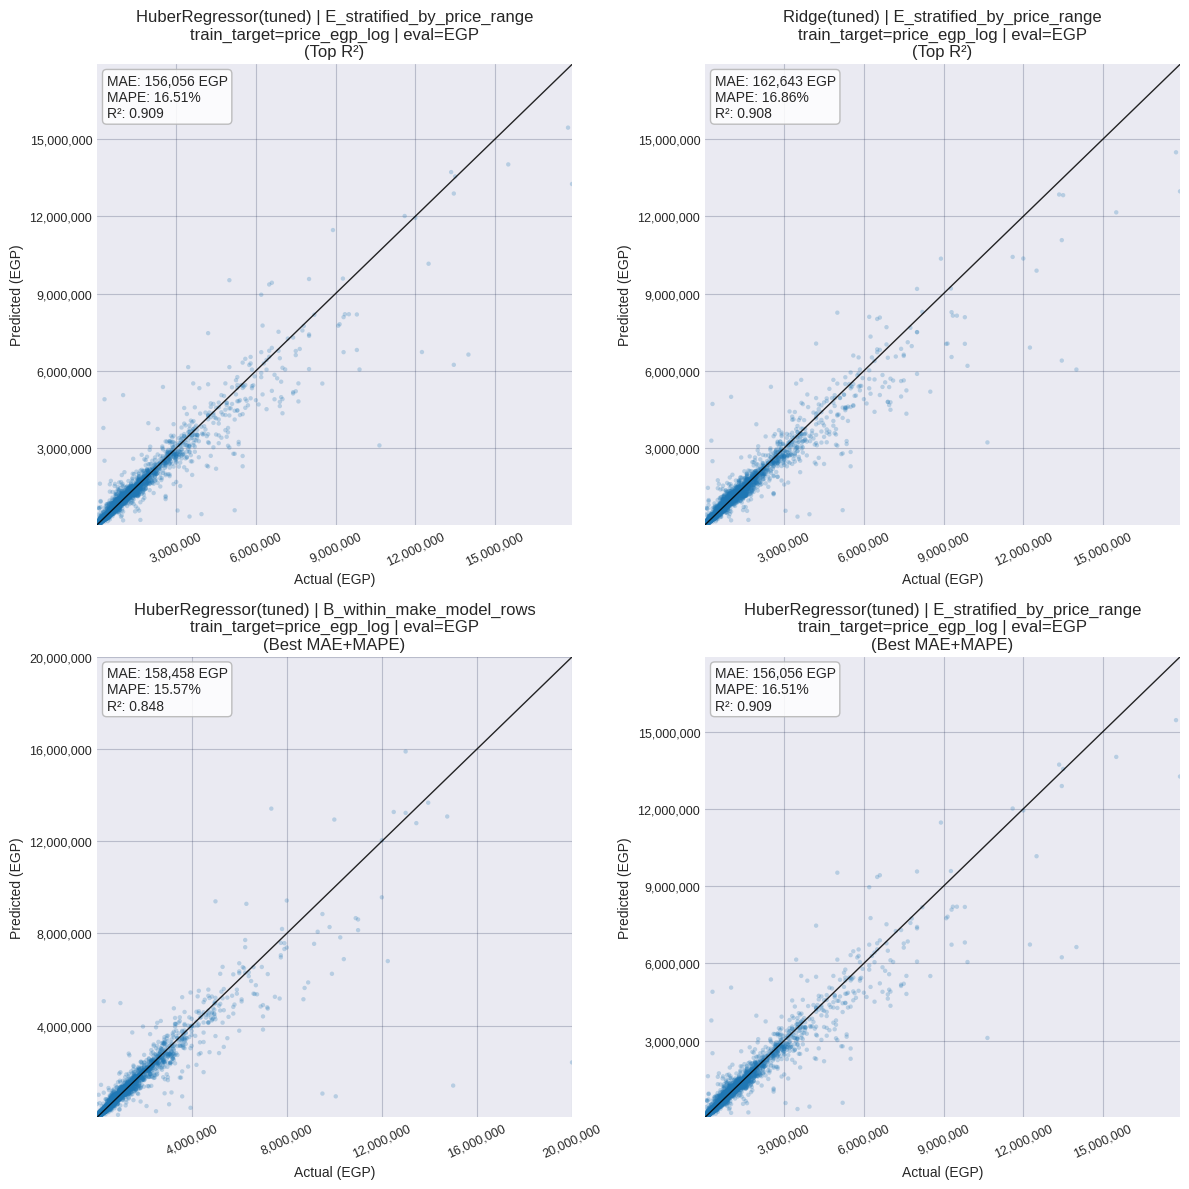

In [209]:
if len(results_by_target) == 0:
    raise RuntimeError("Run the benchmark cells first (price_egp / price_egp_log).")

# Ensure we have a combined table
results_all = pd.concat(list(results_by_target.values()), ignore_index=True, axis=0)
need_cols = {"train_target", "split", "model", "MAE", "MAPE_%", "R2"}
missing_cols = sorted(list(need_cols - set(results_all.columns)))
if missing_cols:
    raise RuntimeError(f"results_all missing columns: {missing_cols}")

cand = results_all.dropna(subset=["MAE", "MAPE_%", "R2"]).copy()
cand = cand.reset_index(drop=True)

def _model_to_pred_key(model_name: str) -> str:
    if model_name == "LinearRegression":
        return "preds_linear_eval"
    if model_name == "Ridge(tuned)":
        return "preds_ridge_eval"
    if model_name in {"HuberRegressor", "HuberRegressor(tuned)"}:
        return "preds_huber_eval"
    raise KeyError(f"Unknown model name: {model_name}")

def _plot_pred_vs_true(ax, *, train_target: str, split_key: str, model_name: str, metrics_row: dict):
    store = pred_store_by_target[train_target][split_key]
    y_true = store["y_true_eval"]
    y_pred = store[_model_to_pred_key(model_name)]

    ax.scatter(y_true, y_pred, s=10, alpha=0.25, edgecolors="none", rasterized=True)

    lo = float(np.min([np.min(y_true), np.min(y_pred)]))
    hi = float(np.max([np.max(y_true), np.max(y_pred)]))
    ax.plot([lo, hi], [lo, hi], color="black", linewidth=1, alpha=0.85)

    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)

    ax.xaxis.set_major_locator(MaxNLocator(nbins=6))
    ax.yaxis.set_major_locator(MaxNLocator(nbins=6))
    ax.xaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
    ax.yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
    ax.tick_params(axis="x", labelrotation=25, labelsize=9)
    ax.tick_params(axis="y", labelsize=9)

    title = f"{model_name} | {split_key}\ntrain_target={train_target} | eval=EGP"
    ax.set_title(title)
    ax.set_xlabel("Actual (EGP)")
    ax.set_ylabel("Predicted (EGP)")
    ax.grid(True, alpha=0.25, color = "#2A3459")

    mae = float(metrics_row.get("MAE", np.nan))
    mape = float(metrics_row.get("MAPE_%", np.nan))
    r2 = float(metrics_row.get("R2", np.nan))
    txt = f"MAE: {mae:,.0f} EGP\nMAPE: {mape:.2f}%\nR²: {r2:.3f}"
    ax.text(
        0.02, 0.98, txt,
        transform=ax.transAxes,
        va="top", ha="left",
        fontsize=10,
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.85, edgecolor="0.7"),
    )

# 1) Top-2 by R² (highest)
top_r2 = cand.sort_values(["R2", "MAE"], ascending=[False, True]).head(2)

# 2) Top-2 by (MAE + MAPE) combined rank (lowest)
cand["_rank_mae"] = cand["MAE"].rank(method="dense", ascending=True)
cand["_rank_mape"] = cand["MAPE_%"].rank(method="dense", ascending=True)
cand["_rank_score"] = (2.0 * cand["_rank_mae"] + 1.0 * cand["_rank_mape"])
top_err = cand.sort_values(["_rank_score", "MAE", "MAPE_%"], ascending=[True, True, True]).head(2)

print("Top 2 by R2:")
display(top_r2[["train_target", "split", "model", "MAE", "MAPE_%", "R2"]].reset_index(drop=True))
print("\nTop 2 by lowest MAE+MAPE (rank score):")
display(top_err[["train_target", "split", "model", "MAE", "MAPE_%", "R2"]].reset_index(drop=True))

fig, axes = plt.subplots(2, 2, figsize=(12, 12))
axes = axes.ravel()

for i, (_, row) in enumerate(top_r2.iterrows()):
    _plot_pred_vs_true(
        axes[i],
        train_target=row["train_target"],
        split_key=row["split"],
        model_name=row["model"],
        metrics_row=row.to_dict(),
    )
axes[0].set_title(axes[0].get_title() + "\n(Top R²)")
axes[1].set_title(axes[1].get_title() + "\n(Top R²)")

for j, (_, row) in enumerate(top_err.iterrows()):
    _plot_pred_vs_true(
        axes[2 + j],
        train_target=row["train_target"],
        split_key=row["split"],
        model_name=row["model"],
        metrics_row=row.to_dict(),
    )
axes[2].set_title(axes[2].get_title() + "\n(Best MAE+MAPE)")
axes[3].set_title(axes[3].get_title() + "\n(Best MAE+MAPE)")

plt.tight_layout()
plt.show()

## 4) Export the fitted preprocessor + Save baseline models
**Canonical preprocessor save:** Preprocessor is saved **once** with the top-ranked model (rank 1)
- Location: `models/preprocessors/preprocessor__v1.0.0.joblib` 
- Metadata: `models/metadata/preprocessor__v1.0.0.json`
- All models reference this single preprocessor version

In [232]:
# NOTE: Preprocessor will be saved as part of the model versioning (cell below)
# This cell just validates the preprocessor works before the full pipeline

# Create directories (may be used for validation later if needed)
out_dir = ML_ROOT / 'models' / 'preprocessors'
out_dir.mkdir(parents=True, exist_ok=True)

# Fit preprocessor on selected split to understand feature dimensions
SPLIT_FOR_INFO = 'E_stratified_by_price_range'  # Use best split for reference info

Xtr, Xte, ytr, yte = splits[SPLIT_FOR_INFO]
preprocessor_fitted = preprocessor.fit(Xtr)

# Validate preprocessor works
Xtr_sample = preprocessor_fitted.transform(Xtr.iloc[:100])
print(f"✓ Preprocessor validated")
print(f"  Output shape (100 rows): {Xtr_sample.shape}")
print(f"  Output type: {'sparse' if hasattr(Xtr_sample, 'toarray') else 'dense'}")
print(f"  Categorical cols: {len(categorical_cols)}")
print(f"  Numeric cols: {len(numeric_cols)}")
print(f"\n→ Preprocessor will be saved with the model artifacts (below)")

✓ Preprocessor validated
  Output shape (100 rows): (100, 648)
  Output type: sparse
  Categorical cols: 9
  Numeric cols: 7

→ Preprocessor will be saved with the model artifacts (below)


In [233]:
# Verify the fitted preprocessor from the split above
Xt_validation = preprocessor_fitted.transform(X.iloc[:5])
print(f"✓ Quick validation: Transformed 5 rows -> shape {Xt_validation.shape}")
print(f"  Ready to save with models in the next section")

✓ Quick validation: Transformed 5 rows -> shape (5, 648)
  Ready to save with models in the next section


## 5) Export & Registry Setup
**Architecture:**
- Validate preprocessor is functional (cell 44)
- Save baseline models + CANONICAL preprocessor to versioned artifacts
- Create unified model registry

**Single Source of Truth:**
- Preprocessor saved ONE TIME: `preprocessor__v1.0.0.joblib` 
- Saved with top-ranked model (rank=1) in the loop below
- All models share the same preprocessor version

In [226]:
# Emergency save setup constants
TOP_N = 2
VERSION_ID = "v1.0.0"
saved_at = datetime.now(timezone.utc).isoformat()

In [227]:
results_all = results_all.copy()
results_all["model"] = results_all["model"].replace({"HuberRegressor": "HuberRegressor(tuned)"})

required_base = ["train_target", "split", "model", "R2", "MAE", "RMSE", "MAPE_%"]
missing_base = [c for c in required_base if c not in results_all.columns]
if missing_base:
    raise RuntimeError(f"results_all missing required columns: {missing_base}")

# Backward-compatible defaults for older results tables
if "best_alpha" not in results_all.columns:
    results_all["best_alpha"] = np.nan
if "cv_MAE" not in results_all.columns:
    results_all["cv_MAE"] = np.nan
if "best_huber_alpha" not in results_all.columns:
    results_all["best_huber_alpha"] = FIXED_HUBER_ALPHA
if "best_huber_epsilon" not in results_all.columns:
    results_all["best_huber_epsilon"] = FIXED_HUBER_EPSILON

REQUIRED_MODELS = ["HuberRegressor(tuned)", "Ridge(tuned)"]
missing_models = [m for m in REQUIRED_MODELS if m not in set(results_all["model"].unique())]
if missing_models:
    raise RuntimeError(
        "Required models are missing from results_all. "
        f"Missing: {missing_models}. Available: {sorted(results_all['model'].unique().tolist())}"
    )

to_save = (
    results_all[results_all["model"].isin(REQUIRED_MODELS)]
    .dropna(subset=["R2"])
    .sort_values(["model", "R2", "MAE"], ascending=[True, False, True])
    .groupby("model", as_index=False, sort=False)
    .head(1)
    .sort_values(["R2", "MAE"], ascending=[False, True])
    .reset_index(drop=True)
)

TOP_N = len(to_save)

print("Models selected for saving:")
display(to_save[[
    "train_target", "split", "model", "R2", "MAE",
]])

Models selected for saving:


,train_target,split,model,R2,MAE
0,price_egp_log,E_stratified_by_price_range,HuberRegressor(tuned),0.909,"156,056.260"
1,price_egp_log,E_stratified_by_price_range,Ridge(tuned),0.908,"162,642.668"


In [228]:
# Create output directories and initialize run containers
pickles_dir = ML_ROOT / "models" / "pickles"
metadata_dir = ML_ROOT / "models" / "metadata"
preprocessors_dir = ML_ROOT / "models" / "preprocessors"

for d in [pickles_dir, metadata_dir, preprocessors_dir]:
    d.mkdir(parents=True, exist_ok=True)

registry_models = []
preproc_pkl_path = None
preproc_meta_path = None

In [ ]:
# Fit selected models, save artifacts, and emit per-model metadata
# ✓ CANONICAL PREPROCESSOR SAVE: happens here when rank==1
# (removed redundant standalone save from earlier cell)

for rank_0, row in to_save.iterrows():
    rank = rank_0 + 1
    model_name = row["model"]
    target_col = row["train_target"]
    split_key = row["split"]
    y_is_log = target_col.endswith("_log")

    tr_idx, te_idx = split_indices[split_key]
    Xtr = df.loc[tr_idx, feature_cols]
    Xte = df.loc[te_idx, feature_cols]
    ytr = df.loc[tr_idx, target_col]
    yte = df.loc[te_idx, target_col]

    print(f"\nRank {rank}: fitting {model_name}...", end=" ", flush=True)
    pipe = build_pipeline(model_name, row)
    pipe.fit(Xtr, ytr)
    print("done.")

    safe_name = (
        model_name
        .replace("(tuned)", "")
        .replace("(", "").replace(")", "")
        .replace(" ", "_")
        .lower()
    )

    pkl_filename = f"Baseline{rank}__{safe_name}.pkl"
    pkl_path = pickles_dir / pkl_filename
    meta_path = metadata_dir / pkl_filename.replace(".pkl", ".json")

    joblib.dump(pipe, pkl_path)
    print(f"  ✓ Model saved -> {pkl_path.name}")

    if rank == 1:
        # ===== CANONICAL PREPROCESSOR SAVE (single location) =====
        preproc_pkl_path = preprocessors_dir / f"preprocessor__{VERSION_ID}.joblib"
        preproc_meta_path = metadata_dir / f"preprocessor__{VERSION_ID}.json"

        joblib.dump(pipe.named_steps["preprocess"], preproc_pkl_path)
        preproc_meta = {
            "version_id": VERSION_ID,
            "fit_date": saved_at,
            "fit_split": split_key,
            "fit_target": target_col,
            "numeric_features": list(numeric_cols),
            "categorical_features": list(categorical_cols),
        }
        with open(preproc_meta_path, "w", encoding="utf-8") as f:
            json.dump(preproc_meta, f, indent=2, ensure_ascii=False)
        print(f"  ✓ Preprocessor saved (canonical) -> {preproc_pkl_path.name}")

    preds = pipe.predict(Xte)
    metrics, _, _ = compute_metrics_in_egp(yte, preds, y_is_log=y_is_log)
    r2_diff = abs(metrics["R2"] - float(row["R2"]))

    if r2_diff > 0.001:
        print(
            f"  WARNING: R2 mismatch: recomputed={metrics['R2']:.4f} "
            f"results_all={row['R2']:.4f} diff={r2_diff:.4f}"
        )
    else:
        print(
            f"  ✓ Metrics verified: R2={metrics['R2']:.4f} "
            f"MAE={metrics['MAE']:,.0f} MAPE={metrics['MAPE_%']:.3f}%"
        )

    model_step = pipe.named_steps.get("model")
    raw_params = model_step.get_params() if model_step else {}
    keep_params = {"alpha", "epsilon", "fit_intercept", "max_iter", "warm_start"}
    hyperparams = {k: v for k, v in raw_params.items() if k in keep_params}

    meta = {
        "version_id": VERSION_ID,
        "rank_by_r2": rank,
        "model_type": model_name,
        "saved_at": saved_at,
        "train_config": {
            "target": target_col,
            "is_log_target": y_is_log,
            "split": split_key,
        },
        "metrics": {
            "r2": float(metrics["R2"]),
            "mae": float(metrics["MAE"]),
            "rmse": float(metrics["RMSE"]),
            "mape_pct": float(metrics["MAPE_%"]),
        },
        "hyperparams": hyperparams,
        "artifacts": {
            "model_pkl": str(pkl_path),
            "preprocessor_pkl": str(preproc_pkl_path),
        },
    }

    with open(meta_path, "w", encoding="utf-8") as f:
        json.dump(meta, f, indent=2, ensure_ascii=False)

    registry_models.append({
        "rank": rank,
        "model_type": model_name,
        "R2": float(metrics["R2"]),
        "MAE": float(metrics["MAE"]),
        "pkl_path": str(pkl_path),
        "meta_path": str(meta_path),
    })


Rank 1: fitting HuberRegressor(tuned)... done.
  ✓ Model saved -> Baseline1__huberregressortuned.pkl
  ✓ Preprocessor saved -> preprocessor__v1.0.0.joblib
  ✓ Metrics verified: R2=0.9088 MAE=156,056 MAPE=16.511%

Rank 2: fitting Ridge(tuned)... 

/home/mo-seif/Documents/GP/GPENV/lib64/python3.14/site-packages/sklearn/linear_model/_huber.py:348: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


done.
  ✓ Model saved -> Baseline2__ridgetuned.pkl
  ✓ Metrics verified: R2=0.9084 MAE=162,643 MAPE=16.856%


In [230]:
# Write registry and print active model summary
if preproc_pkl_path is None or preproc_meta_path is None:
    raise RuntimeError("Preprocessor artifacts were not created.")

registry = {
    "active_version": VERSION_ID,
    "active_model": {
        "rank": registry_models[0]["rank"],
        "model_type": registry_models[0]["model_type"],
        "R2": registry_models[0]["R2"],
        "MAE": registry_models[0]["MAE"],
        "pkl_path": str(Path(registry_models[0]["pkl_path"]).relative_to(ML_ROOT)),
        "meta_path": str(Path(registry_models[0]["meta_path"]).relative_to(ML_ROOT)),
    },
    "versions": {
        VERSION_ID: {
            "trained_at": saved_at,
            "n_samples": int(len(df)),
            "preprocessor": {
                "pkl_path": str(preproc_pkl_path.relative_to(ML_ROOT)),
                "meta_path": str(preproc_meta_path.relative_to(ML_ROOT)),
            },
            "models": [
                {
                    "rank": m["rank"],
                    "model_type": m["model_type"],
                    "R2": m["R2"],
                    "MAE": m["MAE"],
                    "pkl_path": str(Path(m["pkl_path"]).relative_to(ML_ROOT)),
                    "meta_path": str(Path(m["meta_path"]).relative_to(ML_ROOT)),
                }
                for m in registry_models
            ],
        }
    },
}

registry_path = ML_ROOT / "models" / "model_registry.json"
with open(registry_path, "w", encoding="utf-8") as f:
    json.dump(registry, f, indent=2, ensure_ascii=False)

print(f"\n✓ Registry written -> {registry_path}")
print(
    f"  Active: {registry_models[0]['model_type']} "
    f"R2={registry_models[0]['R2']:.4f} MAE={registry_models[0]['MAE']:,.0f}"
)


✓ Registry written -> /home/mo-seif/Documents/GP/ml-service/models/model_registry.json
  Active: HuberRegressor(tuned) R2=0.9088 MAE=156,056
